# 06_circuits_and_unitaries

Purpose:
- Understand quantum circuits as unitary factorizations
- Connect gate sequences to matrix multiplication
- Build intuition for circuit diagrams as time-ordered operators

In [7]:
# Minimal example: H · Z · H = X
# Build the circuit, compute its unitary, and verify equality with X.

import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.circuit.library import HGate, ZGate, XGate

# 1) Build the circuit: H -> Z -> H
qc = QuantumCircuit(1)
qc.h(0)
qc.z(0)
qc.h(0)

# 2) Compute the overall unitary of the circuit
U = Operator(qc).data

# 3) Get the X gate matrix
X = Operator(XGate()).data

# 4) Print results
print("Circuit:")
print(qc)

print("\nUnitary of H-Z-H:")
print(U)

print("\nX gate:")
print(X)

# 5) Verify equality (up to numerical precision)
print("\nH Z H equals X:", np.allclose(U, X))

Circuit:
   ┌───┐┌───┐┌───┐
q: ┤ H ├┤ Z ├┤ H ├
   └───┘└───┘└───┘

Unitary of H-Z-H:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

X gate:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

H Z H equals X: True


### Basis management: understanding H–Z–H

**• What basis H moves you into:**  
The Hadamard gate maps the computational basis $(\{|0\rangle, |1\rangle\})$ to the X-eigenbasis $(\{|+\rangle, |-\rangle\})$. In this basis, states that appeared as relative phase differences in the computational basis become population differences.

**• What Z does in that basis:**  
The Z gate is diagonal in the computational basis, but in the X basis it swaps $(|+\rangle)$ and $(|-\rangle)$. Equivalently, Z acts as a bit flip when expressed in the X basis.

**• Why the second H matters:**  
The final Hadamard transforms the system back to the computational basis, so the net effect of $(H Z H)$ is to exchange $(|0\rangle)$ and $(|1\rangle)$.

This is why $(X = H Z H)$: the X gate can be understood as performing a phase flip in an appropriate basis and then returning to the original basis. Circuits are therefore best understood as explicit basis-management strategies.

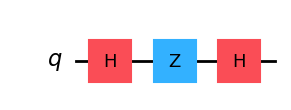

In [10]:
# Draw the previous H-Z-H circuit cleanly in Jupyter (Matplotlib backend)

%matplotlib inline

from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.h(0)
qc.z(0)
qc.h(0)

qc.draw(output="mpl");